# 03 Business Insights

This notebook summarizes the analysis in business language, highlights the most important patterns, and ends with practical recommendations.

In [1]:
from pathlib import Path
import sys

def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root.")

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.append(str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis import (
    business_summary,
    discount_profit_analysis,
    monthly_performance,
    sales_by_category,
    sales_by_region,
    top_products_by_sales,
)
from utils import save_plot

plt.style.use("ggplot")

## Load Cleaned Data

In [2]:
df = pd.read_csv(PROJECT_ROOT / "data" / "cleaned" / "ecommerce_data_cleaned.csv", parse_dates=["Order Date"])
df.head()

,Order ID,Order Date,Customer ID,Product Name,Category,Sales,Quantity,Discount,Profit,Region,Year,Month,Month Name,Profit Margin
0,ORD-20230001,2023-01-31,CUST-1047,Air Fryer,Home & Kitchen,85.42,1,0.00,22.89,West,2023,1,January,0.267970
1,ORD-20230002,2023-01-07,CUST-1388,Wireless Mouse,Electronics,99.86,3,0.15,14.98,East,2023,1,January,0.150010
2,ORD-20230003,2023-02-14,CUST-1373,Lipstick Pack,Beauty,11.69,1,0.25,-3.64,South,2023,2,February,-0.311377
3,ORD-20230004,2023-07-16,CUST-1360,Denim Jacket,Fashion,79.09,1,0.10,20.73,Central,2023,7,July,0.262106
4,ORD-20230005,2024-01-15,CUST-1181,Bluetooth Speaker,Electronics,660.96,6,0.20,82.60,West,2024,1,January,0.124970


## Executive KPI Snapshot

In [3]:
summary = business_summary(df)
total_revenue = summary["total_sales"]
total_profit = summary["total_profit"]
average_order_value = summary["average_order_value"]
profit_margin = summary["profit_margin"] * 100

kpi_snapshot = pd.DataFrame(
    {
        "Metric": ["Total Revenue", "Total Profit", "Average Order Value", "Profit Margin (%)"],
        "Value": [round(total_revenue, 2), round(total_profit, 2), round(average_order_value, 2), round(profit_margin, 2)],
    }
)
kpi_snapshot

,Metric,Value
0,Total Revenue,226161.71
1,Total Profit,46756.39
2,Average Order Value,150.77
3,Profit Margin (%),20.67


## Where The Business Wins

In [4]:
category_summary = sales_by_category(df)
top_categories = category_summary.head(3)
top_categories

,Category,sales,profit,quantity
1,Electronics,105428.62,17299.27,966
3,Home & Kitchen,53105.21,10871.48,739
2,Fashion,27405.68,7941.48,672


In [5]:
top_products = top_products_by_sales(df, top_n=10)
top_products.head(10)

,Product Name,sales,profit
23,Portable SSD,20806.27,3281.11
21,Noise Cancelling Headphones,20702.33,3100.15
27,Smart Watch,19738.67,3766.09
35,Vacuum Cleaner,15741.82,3416.53
20,Mechanical Keyboard,14641.30,2512.18
9,Dining Chair,11003.55,2244.05
2,Bluetooth Speaker,10656.18,1732.80
5,Cookware Set,9348.40,1918.24
37,Webcam,7978.38,1169.91
34,USB-C Hub,6696.80,1111.59


In [6]:
region_summary = sales_by_region(df)
region_summary

,Region,sales,profit,orders
2,North,58604.21,11982.83,357
4,West,49769.27,10605.70,320
3,South,46825.68,9261.15,303
1,East,41052.22,8189.66,281
0,Central,29910.33,6717.05,239


## Trend Analysis

In [7]:
monthly_summary = monthly_performance(df)
best_sales_month = monthly_summary.loc[monthly_summary["sales"].idxmax()]
best_profit_month = monthly_summary.loc[monthly_summary["profit"].idxmax()]

trend_highlights = pd.DataFrame(
    {
        "Insight": ["Best sales month", "Best profit month"],
        "Month": [best_sales_month["Month_Start"].strftime("%Y-%m"), best_profit_month["Month_Start"].strftime("%Y-%m")],
        "Value": [round(best_sales_month["sales"], 2), round(best_profit_month["profit"], 2)],
    }
)
trend_highlights

,Insight,Month,Value
0,Best sales month,2024-03,15420.13
1,Best profit month,2024-03,3268.44


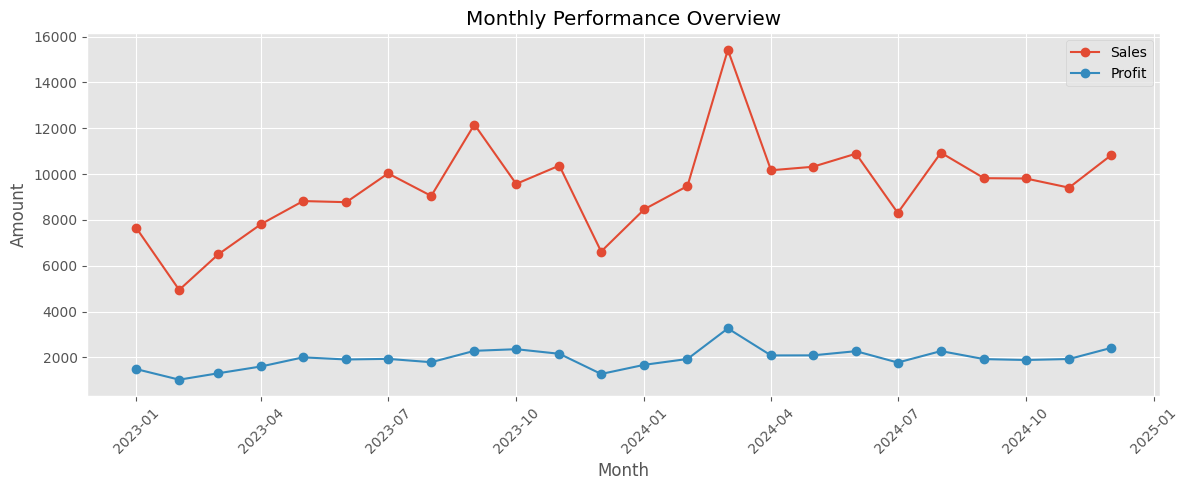

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_summary["Month_Start"], monthly_summary["sales"], marker="o", label="Sales")
ax.plot(monthly_summary["Month_Start"], monthly_summary["profit"], marker="o", label="Profit")
ax.set_title("Monthly Performance Overview")
ax.set_xlabel("Month")
ax.set_ylabel("Amount")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
save_plot(fig, "business_insights_monthly_overview.png")
plt.show()

## Discount Impact

In [9]:
discount_summary = discount_profit_analysis(df)
discount_summary

,Discount Band,sales,profit,average_profit
0,0%,61682.76,16662.54,50.037658
1,1-10%,86158.49,19156.20,35.278453
2,11-20%,54898.84,9230.48,21.516270
3,21-30%,23421.62,1707.17,8.754718
4,30%+,0.00,0.00,NaN


In [10]:
discount_summary["profit_per_sale"] = np.where(
    discount_summary["sales"] > 0,
    discount_summary["profit"] / discount_summary["sales"],
    0,
)
discount_summary

,Discount Band,sales,profit,average_profit,profit_per_sale
0,0%,61682.76,16662.54,50.037658,0.270133
1,1-10%,86158.49,19156.20,35.278453,0.222337
2,11-20%,54898.84,9230.48,21.516270,0.168136
3,21-30%,23421.62,1707.17,8.754718,0.072889
4,30%+,0.00,0.00,NaN,0.000000


## Business Recommendations

1. Protect profit by limiting deeper discounts on products that already operate with thin margins.
2. Invest more in the strongest categories and regions because they contribute the largest share of revenue and profit.
3. Promote the highest-selling products through bundles, cross-sell campaigns, and repeat-purchase offers.
4. Use monthly trend peaks to plan inventory, staffing, and marketing budgets ahead of demand surges.
5. Monitor both revenue and profit together so high sales do not hide weak financial performance.
6. Review low-profit combinations of category, region, and discount band for pricing or assortment changes.

This completes the project workflow from raw data to business recommendations.